# SMF 02a · Stacked SMF of the nine MACH clusters

Completeness-corrected stellar mass function of the stacked MACH sample in a chosen radial range:
1. Assign every galaxy to its (M_r, g − r, R_cl/R200) cell and attach f_mem / f_spec from `MACH_SMF_fspec_fmem_bin.csv`.
2. Monte Carlo: in each of 1000 iterations draw N_cor = round(N_non-spec × f_mem) photometric galaxies per cell and add them to the spectroscopic members; average the histograms.
3. Split into quiescent / star-forming with Dn4000 (measured, or predicted from g − r for photometric galaxies).
4. Mass completeness limit = lowest mass where the correction exceeds 10 % of the members; Schechter fits by MCMC (`emcee`).

The radial range is set in the cell "Select radial range"; each run writes one `.npz` into `SMF_results/` that the later notebooks read.

**Inputs** (not included): `DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv`, `DATA/MACH_PHOT/AllHeCS_VAC_updated.csv`, `MACH_SMF_fspec_fmem_bin.csv`

**Output**: `SMF_results/<SAVE_FILENAME>.npz`

In [12]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

# 1. Load the catalogs

In [2]:
# Load MACH master catalog
mach_path = f"{MAINPATH}/DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv"
mach_data = pd.read_csv(mach_path)

# Correct cmodel magnitudes for extinction
for band in ("g", "r"):
    mach_data[f"cmodelMag_{band}_0"] = (
        mach_data[f"cmodelMag_{band}"] - mach_data[f"extinction_{band}"]
    )

# Load HeCS VAC catalog
hecs_vac_path = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"
hecs_vac_data = pd.read_csv(hecs_vac_path)

df0 = mach_data.copy()

# Construct Mock_z: use Z_TOT_Z, but if Z_TOT_Z == -99, use cluster mean z from hecs_vac_data (by CLID)
df0["Mock_z"] = df0["Z_TOT_Z"]

# Find rows with Z_TOT_Z == -99
mask_noz = (df0["Z_TOT_Z"] == -99)

# For those rows, replace with matching cluster z from hecs_vac_data
if "CLID" in df0.columns and "CLID" in hecs_vac_data.columns:
    # Construct cluster z dictionary from hecs_vac_data
    clid_to_z = hecs_vac_data.set_index("CLID")["Z"].to_dict()
    # Fill Mock_z for those without z
    df0.loc[mask_noz, "Mock_z"] = df0.loc[mask_noz, "CLID"].map(clid_to_z)

# Compute absolute r-band magnitude using Mock_z
lum_dist_pc = cosmo.luminosity_distance(df0["Mock_z"]).to("pc").value
df0["AbsMag_r"] = df0["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_71570/2345126073.py:32: RuntimeWarning: divide by zero encountered in log10
  df0["AbsMag_r"] = df0["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_71570/2345126073.py:32: RuntimeWarning: invalid value encountered in log10
  df0["AbsMag_r"] = df0["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)


The inner region (R_cl/R200 ≤ 1.0) is the training set for the Dn4000 vs. (g − r) regression that predicts Dn4000 for galaxies without a spectrum.

In [3]:
from scipy import stats

# =============================================================
# Build a clean training sample for g−r vs. Dn4000 regression
#   1) Use only galaxies inside Rcl/R200 ≤ 1.0
#   2) Require reliable Dn4000 measurements (≠ -99)
#   3) Apply simple 3σ clipping in both g−r and Dn4000
#   4) Optionally trim to 1–99 percentile range in both axes
# =============================================================

# 1) Select inner-region galaxies and compute (g−r) colour
inner_region = mach_data[mach_data['Rcl/R200'] <= 1.0].copy()
inner_region['g_r'] = inner_region['cmodelMag_g_0'] - inner_region['cmodelMag_r_0']

# 2) Keep only rows with measured Dn4000
train = inner_region[inner_region['Z_TOT_DN4000'] != -99.0].copy()

# 3) Simple 3σ clipping on both axes
for col in ['g_r', 'Z_TOT_DN4000']:
    vals = train[col].astype(float)
    mean = np.nanmean(vals)
    std  = np.nanstd(vals)
    mask = (vals > mean - 3 * std) & (vals < mean + 3 * std)
    train = train[mask].copy()

# 4) Optional: trim extreme 1% tails in both axes
for col in ['g_r', 'Z_TOT_DN4000']:
    vmin, vmax = np.percentile(train[col], [1, 99])
    mask = (train[col] >= vmin) & (train[col] <= vmax)
    train = train[mask].copy()

# 5) Linear regression: Dn4000 = slope * (g−r) + intercept
slope, intercept, r_val, *_ = stats.linregress(
    train['g_r'].values,
    train['Z_TOT_DN4000'].values
)

print(
    f"DN4000 regression:  DN4000 = {slope:.4f} * (g-r) + {intercept:.4f}  "
    f"(R² = {r_val**2:.3f},  N_train = {len(train)})"
)

DN4000 regression:  DN4000 = 0.2834 * (g-r) + 1.1331  (R² = 0.130,  N_train = 14442)


# 2. Select the radial range of the sample

Change the condition below for other SMFs (within R500, 2 R200, or a radial shell such as 0.5–1 R200) and give the output file a matching name.

In [23]:
# Radial range of the sample (left-closed, right-open); the file name records the choice.
# The paper uses R200 / R500 (MACH_total_results_R200.npz, ..._R500.npz) and the three
# radial bins 0-0.5, 0.5-1 and 1-2 R200 (MACH_total_Rbin_*.npz).
df = df0.loc[df0["Rcl/R200"].between(1.0, 2.0, inclusive='left')].copy()

SAVE_FILENAME = 'MACH_total_Rbin_1p0to2p0R200.npz'

# 3. Stacked SMF with membership correction

### Monte Carlo correction

In [24]:
from scipy import stats
from tqdm import tqdm

# =============================================================
# Configuration
# =============================================================
TARGET        = 'MACH'
iterations    = 1000                              # Monte Carlo iterations
bin_min, bin_max, bin_width = 7, 13, 0.2         # stellar-mass histogram axis
bins          = np.arange(bin_min, bin_max + bin_width, bin_width)
bin_centers   = bins[:-1] + bin_width / 2

# 3D bin edges that were used when building df_correction
# (must be identical to those in 01_build_SMF_correct_param)
abs_mag_r_bins = np.arange(-30, 10, 1.00)        # absolute r-band magnitude
gr_bins        = np.arange(-6.5, 15.25, 0.25)    # (g-r) colour
rcl_r200_bins  = np.arange(0, 3.2, 0.20)         # projected cluster-centric radius / R200

# =============================================================
# Load membership-correction table
#   Columns: Mr_bin, color_bin, Rcl_bin, f_mem, f_spec
#   f_spec = spectroscopic completeness (Nspec / Nphot) per bin
#   f_mem  = membership probability for non-spectroscopic objects per bin
# =============================================================
df_correction = pd.read_csv('./MACH_SMF_fspec_fmem_bin.csv')

# The CSV stores bin labels as plain strings, e.g. "(-22.0, -21.0]".
# Force string type and strip any stray whitespace so the merge is robust.
bin_keys = ['Mr_bin', 'color_bin', 'Rcl_bin']
for _k in bin_keys:
    df_correction[_k] = df_correction[_k].astype(str).str.strip()

# =============================================================
# Step 1 – Prepare working catalogue
# =============================================================
# Start from df (radial range selected in the earlier cell).
# Drop rows with missing extinction-corrected photometry.
definition = df.copy()
definition = definition[
    (definition['cmodelMag_g'] != -9999.0) &
    (definition['cmodelMag_r'] != -9999.0)
].copy()

num_clusters = len(MACHLIST)

# =============================================================
# Step 2 – Derive (g-r) colour and assign galaxies to 3D bins
# =============================================================
# Extinction-corrected (g-r) colour
definition['g_r'] = definition['cmodelMag_g_0'] - definition['cmodelMag_r_0']

# Assign each galaxy to its (AbsMag_r, g-r, Rcl/R200) bin cell.
# pd.cut returns Interval objects; convert to the same string format as
# df_correction so the merge below finds exact matches.
def _iv_to_str(iv):
    """Convert a pandas Interval to the same string label used in the CSV."""
    return np.nan if pd.isna(iv) else f"({iv.left}, {iv.right}]"

definition['Mr_bin']    = pd.cut(definition['AbsMag_r'],  bins=abs_mag_r_bins).apply(_iv_to_str)
definition['color_bin'] = pd.cut(definition['g_r'],       bins=gr_bins       ).apply(_iv_to_str)
definition['Rcl_bin']   = pd.cut(definition['Rcl/R200'],  bins=rcl_r200_bins ).apply(_iv_to_str)

# =============================================================
# Step 3 – Build DN4000_predicted
#   Use the measured Z_TOT_DN4000 where available (≠ -99.0).
#   For galaxies without a spectrum, predict DN4000 from a linear
#   regression on (g-r) colour trained on the spectroscopic sub-sample.
# =============================================================

predict_mask = definition['Z_TOT_DN4000'] != -99.0
definition['DN4000_predicted'] = np.where(
    predict_mask,
    definition['Z_TOT_DN4000'],              # measured value
    intercept + slope * definition['g_r']    # regression prediction
)

# =============================================================
# Step 4 – Attach f_mem and f_spec from the correction table
#   Left-join on the 3 bin columns; rows whose bin is absent from
#   df_correction will have f_mem = f_spec = NaN (handled in Step 5).
# =============================================================
definition = definition.merge(
    df_correction[bin_keys + ['f_mem', 'f_spec']],
    on=bin_keys,
    how='left'
)

# =============================================================
# Step 5 – Compute N_cor (number of non-spec objects to draw) per bin
#
#   For each (Mr_bin, color_bin, Rcl_bin) cell:
#     Nphot = total galaxies in the cell
#     Nspec = galaxies with a measured redshift  (Z_TOT_Z ≠ -99.0)
#     Nnon  = Nphot - Nspec  →  photometric-only (no redshift) objects
#     N_cor = round( Nnon * f_mem )
#           = estimated number of true cluster members hiding in
#             the non-spectroscopic pool that should be added back
#
#   Bins not present in df_correction have f_mem = NaN → treated as 0,
#   so N_cor = 0 (no objects drawn from those cells).
# =============================================================
def _compute_ncor(group):
    Nphot  = len(group)
    Nspec  = (group['Z_TOT_Z'] != -99.0).sum()
    Nnon   = Nphot - Nspec                       # non-spectroscopic objects
    f_mem  = group['f_mem'].iat[0]
    f_spec = group['f_spec'].iat[0]
    if pd.isna(f_mem):  f_mem  = 0.0
    if pd.isna(f_spec): f_spec = 0.0
    N_cor  = int(round(Nnon * f_mem))
    return pd.Series({'Nphot': Nphot, 'Nspec': Nspec, 'Nnon': Nnon,
                      'f_mem': f_mem, 'f_spec': f_spec, 'N_cor': N_cor})

bin_stats = (
    definition
    .groupby(bin_keys, observed=True)
    .apply(_compute_ncor, include_groups=False)
    .reset_index()
)

# Broadcast per-bin statistics back onto every row of definition
# so we can inspect Nphot / Nspec / N_cor column-by-column.
definition = definition.merge(
    bin_stats[bin_keys + ['Nphot', 'Nspec', 'Nnon', 'N_cor']],
    on=bin_keys, how='left'
)
for _col in ['Nphot', 'Nspec', 'Nnon', 'N_cor']:
    definition[_col] = definition[_col].fillna(0).astype(int)

# Diagnostic summary
n_bins_nonzero = (bin_stats['N_cor'] > 0).sum()
print(f"Bins with N_cor > 0 : {n_bins_nonzero} / {len(bin_stats)}")
print(f"Rows with N_cor > 0 : {(definition['N_cor'] > 0).sum()} / {len(definition)}")
print(f"Total N_cor (sum)   : {definition['N_cor'].sum()}")
display(
    bin_stats[bin_stats['N_cor'] > 0][bin_keys + ['Nphot','Nspec','Nnon','f_mem','f_spec','N_cor']]
    .sort_values('N_cor', ascending=False)
    .head(20)
)

# Fast bin-key → N_cor lookup used inside the MC loop
ncor_lookup = {
    tuple(row[bin_keys]): int(row['N_cor'])
    for _, row in bin_stats.iterrows()
}

# =============================================================
# Step 6 – Separate spectroscopic members and non-spectroscopic pool
# =============================================================
# Confirmed spectroscopic cluster members (MEMBER == 'Y')
member_y_df = definition[definition['MEMBER'] == 'Y'].copy()
Nmem_raw    = len(member_y_df)

# Non-spectroscopic candidate pool:
#   – no measured redshift  (Z_TOT_Z == -99.0)
#   – not already a confirmed spectroscopic member
nonspec_pool = definition[
    (definition['Z_TOT_Z'] == -99.0) & (definition['MEMBER'] == 'N')
]

# Pre-group into a dict keyed by (Mr_bin, color_bin, Rcl_bin) for fast MC access
nonspec_grouped = {
    key: grp.reset_index(drop=True)
    for key, grp in nonspec_pool.groupby(bin_keys, observed=True)
}

# =============================================================
# Step 7 – Monte Carlo membership correction
#
#   In each iteration, randomly sample N_cor objects from the
#   non-spectroscopic pool for every non-empty bin cell.
#   Combine with confirmed members → completeness-corrected catalogue.
# =============================================================
hist_corrected = []    # total corrected SMF (all galaxies)
hist_quenched  = []    # quenched sub-population  (DN4000 > 1.5)
hist_sf        = []    # star-forming sub-population (DN4000 ≤ 1.5)

# Baseline: spec-member-only SMF (per cluster, averaged)
original_counts, _ = np.histogram(member_y_df['M_MASS_CIGALE_PARK'], bins=bins)
original_counts    = original_counts.astype(float) / num_clusters

for _ in tqdm(range(iterations), desc="Monte Carlo"):
    sampled_frames = []

    for bin_key, group in nonspec_grouped.items():
        n_cor = ncor_lookup.get(bin_key, 0)
        if n_cor > 0:
            # Never request more objects than the pool contains
            n_draw = min(n_cor, len(group))
            sampled_frames.append(group.sample(n=n_draw, replace=False))

    if sampled_frames:
        sampled_df    = pd.concat(sampled_frames, ignore_index=True)
        final_catalog = pd.concat([member_y_df, sampled_df], ignore_index=True)
    else:
        final_catalog = member_y_df.copy()

    # Stellar-mass histograms, normalised per cluster
    counts_all, _ = np.histogram(final_catalog['M_MASS_CIGALE_PARK'], bins=bins)
    hist_corrected.append(counts_all.astype(float) / num_clusters)

    q  = final_catalog[final_catalog['DN4000_predicted'] >  1.5]
    sf = final_catalog[final_catalog['DN4000_predicted'] <= 1.5]

    counts_q,  _ = np.histogram(q ['M_MASS_CIGALE_PARK'], bins=bins)
    counts_sf, _ = np.histogram(sf['M_MASS_CIGALE_PARK'], bins=bins)

    hist_quenched.append(counts_q .astype(float) / num_clusters)
    hist_sf.append      (counts_sf.astype(float) / num_clusters)

# =============================================================
# Step 8 – Mean histograms across MC iterations
# =============================================================
mean_all = np.mean(hist_corrected, axis=0)
mean_q   = np.mean(hist_quenched,  axis=0)
mean_sf  = np.mean(hist_sf,        axis=0)

# =============================================================
# Step 9 – Stellar-mass completeness limit
#   Find the lowest-mass bin where the photometric correction
#   (non-spec additions) exceeds 10 % of the raw spec-member count.
#   Bins below this limit are considered incomplete.
# =============================================================
excess_counts = (mean_all - original_counts) * num_clusters
excess_counts  = np.clip(excess_counts, 0, None)       # ignore negative residuals

# Cumulative excess from high mass → low mass
cumulative_excess = np.cumsum(excess_counts[::-1])[::-1]
threshold = 0.1 * Nmem_raw

idx = np.where(cumulative_excess >= threshold)[0][-1] if np.any(cumulative_excess >= threshold) else 0
SMF_complimit = round(bin_centers[idx] - 0.5 * bin_width, 3)
print(f"SMF mass completeness limit: log(M*/M☉) = {SMF_complimit}")

# =============================================================
# Outputs
#   original_counts  – baseline spec-member SMF (per cluster)
#   mean_all         – completeness-corrected total SMF (MC mean, per cluster)
#   mean_q           – corrected quenched SMF
#   mean_sf          – corrected star-forming SMF
#   SMF_complimit    – mass completeness limit [log M*]
#   definition       – working catalogue with Nphot, Nspec, Nnon, N_cor columns
# =============================================================

Bins with N_cor > 0 : 95 / 1503
Rows with N_cor > 0 : 27654 / 76005
Total N_cor (sum)   : 4278407


,Mr_bin,color_bin,Rcl_bin,Nphot,Nspec,Nnon,f_mem,f_spec,N_cor
334,"(-17.0, -16.0]","(1.0, 1.25]","(1.6, 1.8]",1155.0,3.0,1152.0,0.500000,0.006824,576.0
327,"(-17.0, -16.0]","(0.75, 1.0]","(1.2, 1.4]",945.0,8.0,937.0,0.428571,0.006824,402.0
328,"(-17.0, -16.0]","(0.75, 1.0]","(1.4, 1.6]",1129.0,3.0,1126.0,0.333333,0.006824,375.0
350,"(-17.0, -16.0]","(1.75, 2.0]","(1.8, 2.0]",292.0,1.0,291.0,1.000000,0.006824,291.0
325,"(-17.0, -16.0]","(0.5, 0.75]","(1.8, 2.0]",1448.0,6.0,1442.0,0.200000,0.006824,288.0
481,"(-18.0, -17.0]","(1.0, 1.25]","(1.4, 1.6]",273.0,3.0,270.0,1.000000,0.051607,270.0
326,"(-17.0, -16.0]","(0.75, 1.0]","(1.0, 1.2]",683.0,8.0,675.0,0.375000,0.006824,253.0
322,"(-17.0, -16.0]","(0.5, 0.75]","(1.2, 1.4]",850.0,18.0,832.0,0.285714,0.006824,238.0
318,"(-17.0, -16.0]","(0.25, 0.5]","(1.4, 1.6]",718.0,19.0,699.0,0.333333,0.006824,233.0
191,"(-16.0, -15.0]","(1.0, 1.25]","(1.4, 1.6]",224.0,1.0,223.0,1.000000,0.006547,223.0


Monte Carlo: 100%|██████████| 1000/1000 [00:31<00:00, 31.82it/s]

SMF mass completeness limit: log(M*/M☉) = 9.4


### Schechter fits (MCMC)

100%|██████████| 500/500 [00:02<00:00, 245.41it/s]


     Original:  φ₀=75.4(+32.0/-29.0)  M*=10.595(+0.221/-0.217)  α=-0.718(+0.310/-0.254)


100%|██████████| 500/500 [00:01<00:00, 254.97it/s]


          All:  φ₀=42.3(+46.9/-22.1)  M*=10.785(+0.298/-0.334)  α=-1.186(+0.306/-0.211)


100%|██████████| 500/500 [00:01<00:00, 253.86it/s]


    Quiescent:  φ₀=56.1(+22.2/-23.5)  M*=10.607(+0.291/-0.257)  α=-0.560(+0.429/-0.345)


100%|██████████| 500/500 [00:01<00:00, 273.48it/s]


 Star-forming:  φ₀=81.2(+90.3/-56.7)  M*=9.903(+0.534/-0.424)  α=-1.076(+0.877/-0.556)


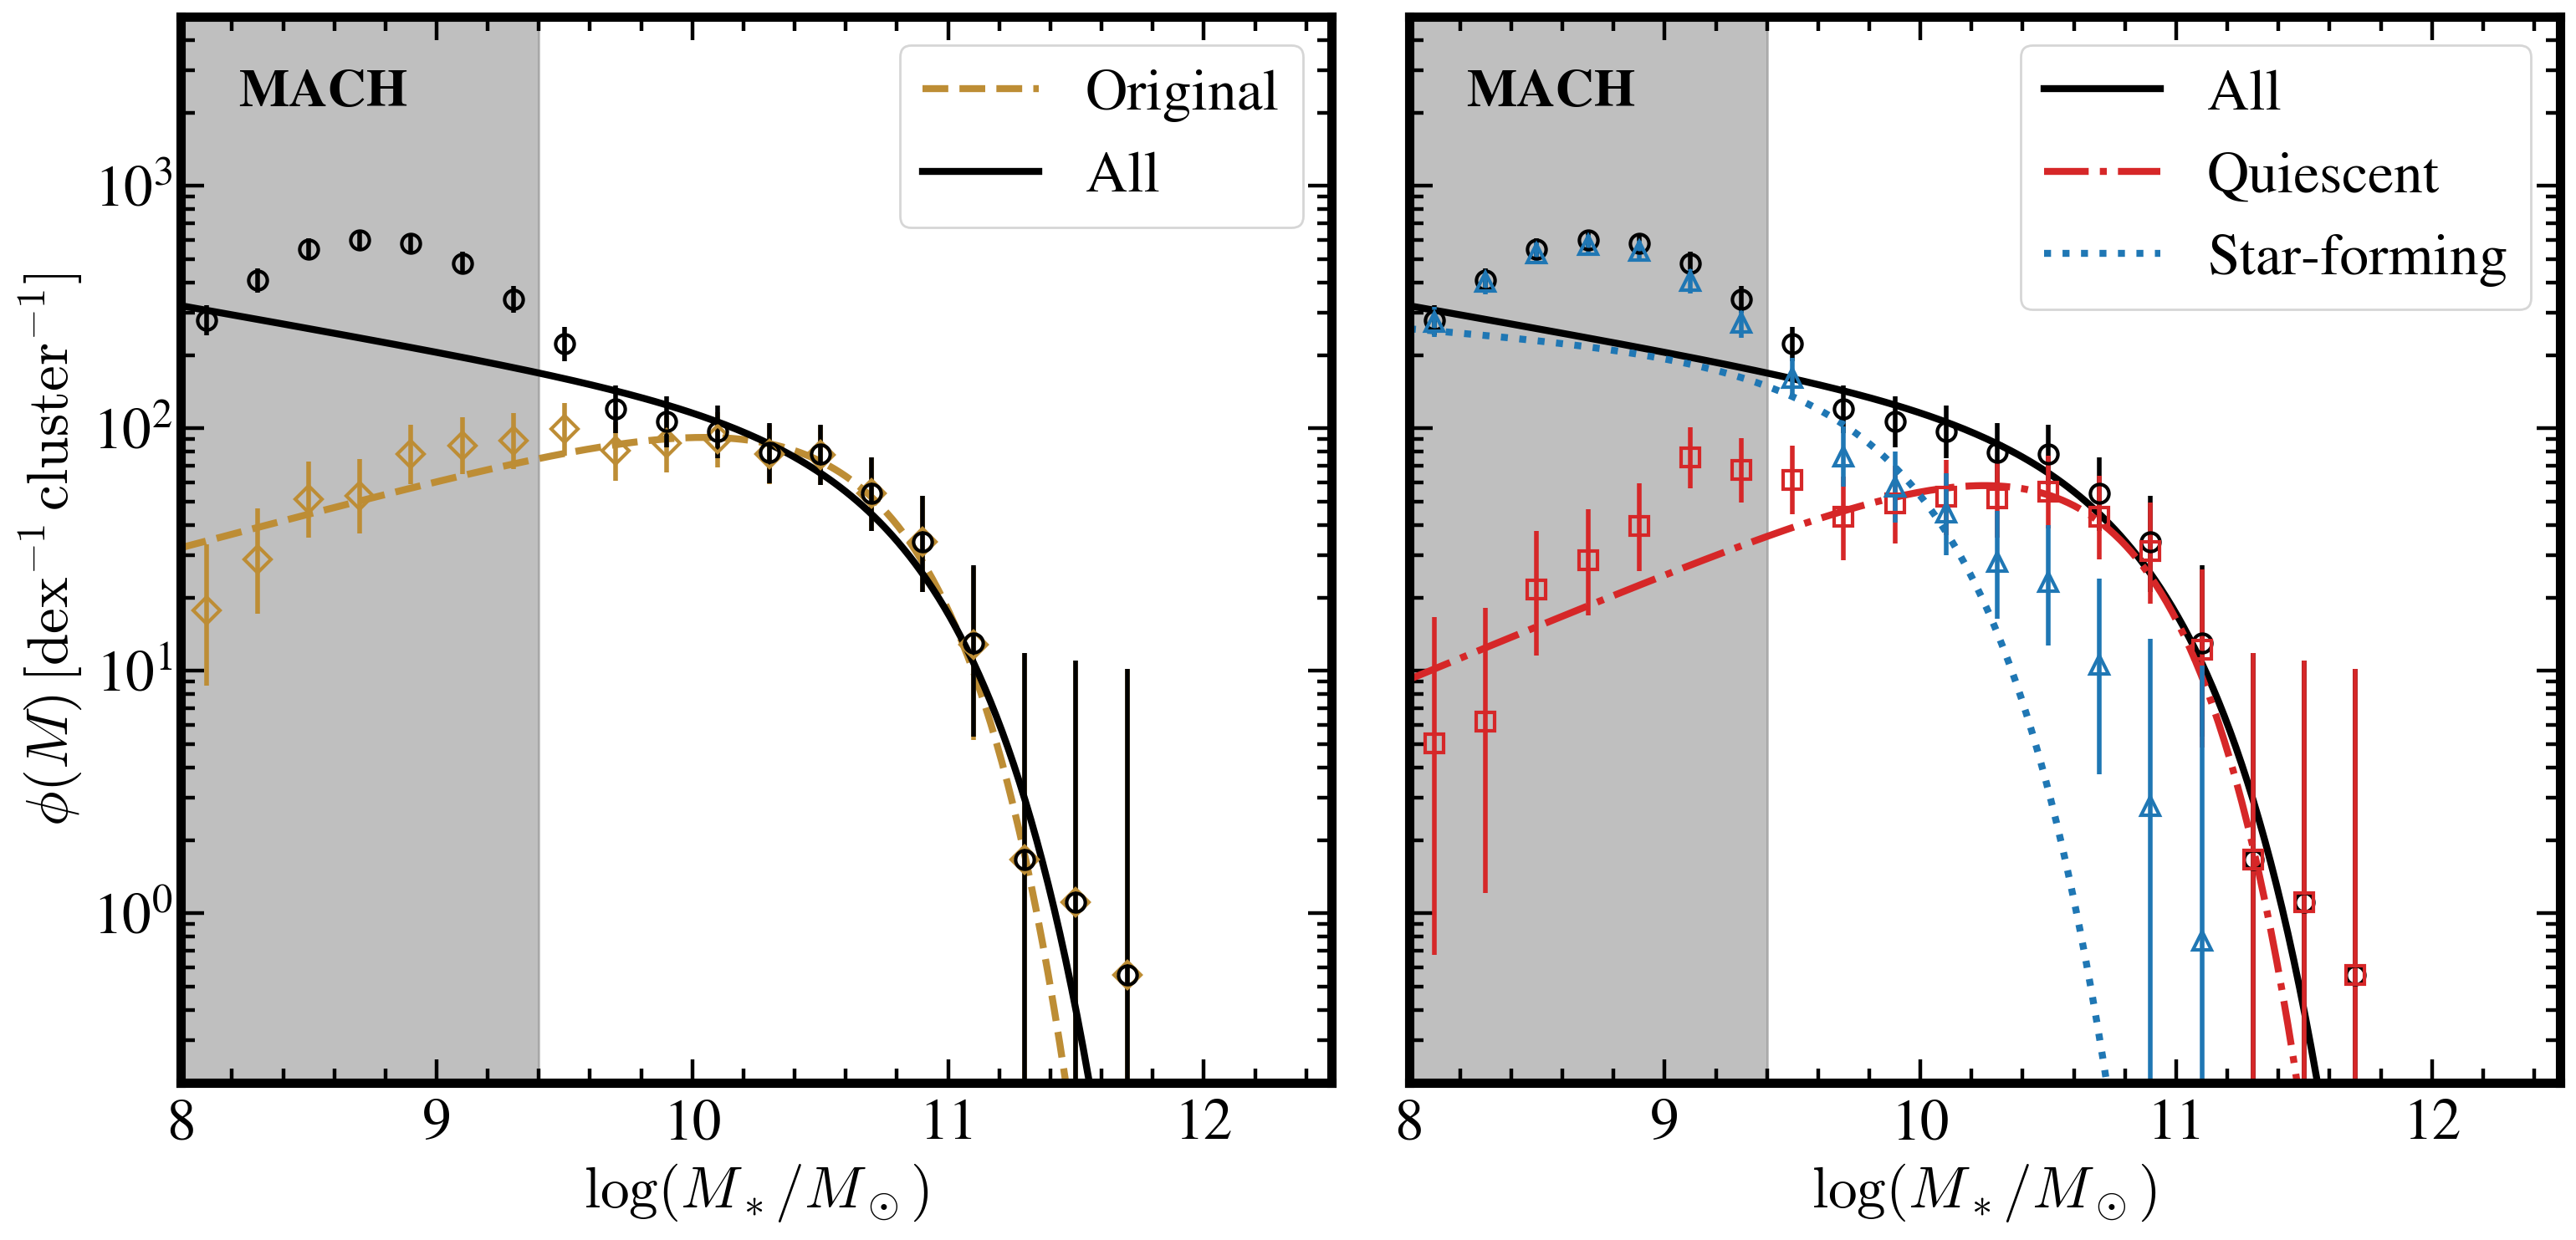

In [25]:
import emcee

# =============================================================
# MCMC Schechter-function fitting
#   Fits a single Schechter function to each of four SMF datasets
#   (Original, All, Quiescent, Star-forming) using emcee MCMC.
#   Returns median parameter estimates with 1-σ asymmetric errors.
# =============================================================

# --- MCMC hyperparameters ---
ndim       = 3     # free parameters: (phi_0, M_star, alpha)
nwalkers   = 256   # number of ensemble walkers
burn_steps = 100   # burn-in steps (discarded)
prod_steps = 500   # production steps (used for posteriors)

# --- Initial parameter guesses per dataset: (phi_0, M_star, alpha) ---
initial_guesses = {
    'All':          np.array([333, 10.65, -1.00]),
    'Quiescent':    np.array([100, 10.70, -1.00]),
    'Star-forming': np.array([200, 10.10, -1.40]),
    'Original':     np.array([150, 10.50, -1.00]),
}

# --- Plot style per dataset ---
colors = {
    'All':          '#000000',   # black
    'Original':     '#bd8d35',   # brown/gold
    'Star-forming': '#1f77b4',   # blue
    'Quiescent':    '#d62728',   # red
}
marker_symbols = {
    'All':          'o',
    'Quiescent':    's',
    'Star-forming': '^',
    'Original':     'D',
}
line_styles = {
    'All':          '-',    # solid
    'Original':     '--',   # dashed
    'Quiescent':    '-.',   # dash-dot
    'Star-forming': ':',    # dotted
}

# --- Panel groupings for the multi-panel comparison plot ---
panels = {
    0: ['Original', 'All'],
    1: ['All', 'Quiescent', 'Star-forming'],
}

# Legend labels (internal dataset keys stay Original / All / …)
legend_labels = {
    'Original': 'Raw SMF',
    'All': 'Corrected SMF',
    'Quiescent': 'Quiescent',
    'Star-forming': 'Star-forming',
}

# =============================================================
# Schechter function model
#   Φ(M) = ln(10) · φ₀ · 10^[(1+α)(M−M*)] · exp(−10^(M−M*))
#   where M = log₁₀(M★/M☉)
# =============================================================
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    x = M - M_star
    return np.log(10) * phi_0 * 10 ** ((1 + alpha) * x) * np.exp(-10 ** x)

# =============================================================
# Bayesian components for emcee
# =============================================================
def log_prior(theta):
    """Flat (uniform) prior; returns 0 inside bounds, -inf outside."""
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 1e4 and 8 < M_star < 14 and -5 < alpha < 5:
        return 0.0
    return -np.inf

def log_likelihood(theta, x, y, yerr):
    """Gaussian log-likelihood with per-point errors."""
    model = schechter_1D_SMF(x, *theta)
    return -0.5 * np.sum((y - model) ** 2 / yerr ** 2 + np.log(2 * np.pi * yerr ** 2))

def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, x, y, yerr) if np.isfinite(lp) else -np.inf

# =============================================================
# MCMC fitting routine
#   Returns (median, lower_1sigma, upper_1sigma) for each parameter.
# =============================================================
def fit_schechter_mcmc(x, y, yerr, initial):
    # Initialise walkers near the starting point with tiny Gaussian scatter
    pos     = initial + 1e-4 * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(x, y, yerr))

    # Burn-in: let walkers explore and discard early samples
    sampler.run_mcmc(pos, burn_steps, progress=True)
    sampler.reset()

    # Production run
    sampler.run_mcmc(None, prod_steps, progress=True)
    samples = sampler.get_chain(flat=True)

    # Summarise posteriors via 16th / 50th / 84th percentiles (≈ median ± 1σ)
    p16, p50, p84 = np.percentile(samples, [16, 50, 84], axis=0)
    return p50, p50 - p16, p84 - p50    # median, lower_err, upper_err

# =============================================================
# Run fits for every dataset
#   Input histograms are normalised to a number density:
#     Φ = counts / bin_width   [dex⁻¹ per cluster]
#   Poisson-like upper error:
#     σ = (√(N + 0.75) + 1) / bin_width   (Gehrels 1986 approximation)
#   Only bins above SMF_complimit with Φ > 0 are fitted.
# =============================================================
datasets = {
    'Original':     original_counts,
    'All':          mean_all,
    'Quiescent':    mean_q,
    'Star-forming': mean_sf,
}
TARGET = 'MACH'

fit_results = {}
for label, hist in datasets.items():
    hist_norm = hist / bin_width
    yerr_norm = (np.sqrt(hist + 0.75) + 1) / bin_width    # Gehrels upper error
    mask      = (bin_centers > SMF_complimit) & (hist_norm > 0)
    fit_results[label] = fit_schechter_mcmc(
        bin_centers[mask], hist_norm[mask], yerr_norm[mask],
        initial_guesses[label]
    )
    med, lo, hi = fit_results[label]
    print(f"{label:>13s}:  φ₀={med[0]:.1f}(+{hi[0]:.1f}/-{lo[0]:.1f})  "
          f"M*={med[1]:.3f}(+{hi[1]:.3f}/-{lo[1]:.3f})  "
          f"α={med[2]:.3f}(+{hi[2]:.3f}/-{lo[2]:.3f})")

# --- 2) Plot using pre-computed fits ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
for idx, labels in panels.items():
    ax = axes[idx]
    # shade region below completeness limit
    ax.axvspan(8, SMF_complimit, color='gray', alpha=0.5)
    for label in labels:
        hist      = datasets[label]
        hist_norm = hist / bin_width
        yerr_up   = (np.sqrt(hist + 0.75) + 1) / bin_width
        yerr_low  = np.sqrt(np.clip(hist - 0.25, 0.25, None)) / bin_width
        # Left panel only: hollow squares for Original vs All; right panel keeps marker_symbols
        m = 's' if idx == 0 else marker_symbols[label]

        # data points (hollow)
        ax.errorbar(
            bin_centers[hist > 0], hist_norm[hist > 0],
            yerr=[yerr_low[hist > 0], yerr_up[hist > 0]],
            fmt=m,
            color=colors[label],
            markerfacecolor='none',
            markeredgecolor=colors[label],
            markersize=8,
            markeredgewidth=1.5,
            ecolor=colors[label],
            capsize=0
        )

        # best-fit curve over full mass range
        phi0, Mstar, alpha = fit_results[label][0]
        M_fit = np.linspace(8, 12.5, 200)
        ax.plot(
            M_fit,
            schechter_1D_SMF(M_fit, phi0, Mstar, alpha),
            color=colors[label],
            lw=3,
            linestyle=line_styles[label],
            label=legend_labels[label]
        )

    # styling
    ax.set_yscale('log')
    ax.set_xlim(8, 12.5)
    ax.set_ylim(0.2, 5000)
    ax.set_xlabel(r'$\log(M_*/M_\odot)$')
    if idx == 0:
        ax.set_ylabel(r'$\phi(M)\,[\mathrm{dex}^{-1}\,\mathrm{cluster}^{-1}]$')
    ax.legend()
    
    # Add annotations for MACH (top-left) and parameter values (bottom-left)
    ax.text(0.05, 0.95, f'{TARGET}', transform=ax.transAxes, fontsize=23, weight='bold', va='top', ha='left', color='black')

plt.tight_layout()
plt.show()

In [26]:
# =============================================================
# Save results for later plotting
#
# Save to ./SMF_results/MACH_total_results.npz.
# Ensure the directory exists (exist_ok=True).
# =============================================================

# Ensure output directory exists
os.makedirs('./SMF_results', exist_ok=True)

result = {
    'mean_all': mean_all,
    'mean_quenched': mean_q,
    'mean_sf': mean_sf,
    'original_counts': original_counts,
    'bin_centers': bin_centers,
    'complim': SMF_complimit,
    'fit_results': fit_results,
}

# --- Save as NumPy .npz (recommended) ---
# Flatten fit_results into arrays so everything is numeric and portable.
fit_labels = list(fit_results.keys())
fit_median = np.array([fit_results[lbl][0] for lbl in fit_labels])
fit_lower  = np.array([fit_results[lbl][1] for lbl in fit_labels])
fit_upper  = np.array([fit_results[lbl][2] for lbl in fit_labels])

outpath_npz = f'./SMF_results/{SAVE_FILENAME}'
np.savez(
    outpath_npz,
    mean_all=mean_all,
    mean_quenched=mean_q,
    mean_sf=mean_sf,
    original_counts=original_counts,
    bin_centers=bin_centers,
    complim=np.array(SMF_complimit),
    fit_labels=np.array(fit_labels, dtype=object),
    fit_median=fit_median,
    fit_lower=fit_lower,
    fit_upper=fit_upper,
)
print(f"Saved: {outpath_npz}")

Saved: ./SMF_results/MACH_total_Rbin_1p0to2p0R200.npz


# 4. Read a saved result and plot

In [ ]:
# =============================================================
# Load saved results (use this in another notebook/session to plot)
# =============================================================

def load_mach_total_results(path='MACH_total_results.npz'):
    """Load .npz and return the same structure as `result` (for plotting)."""
    d = np.load(path, allow_pickle=True)
    fit_labels = list(d['fit_labels'])
    fit_results = {
        lbl: (d['fit_median'][i], d['fit_lower'][i], d['fit_upper'][i])
        for i, lbl in enumerate(fit_labels)
    }
    return {
        'mean_all': d['mean_all'],
        'mean_quenched': d['mean_quenched'],
        'mean_sf': d['mean_sf'],
        'original_counts': d['original_counts'],
        'bin_centers': d['bin_centers'],
        'complim': float(d['complim']),
        'fit_results': fit_results,
    }

# Example: load and set variables so the plotting cell works unchanged
result = load_mach_total_results('./SMF_results/MACH_total_Rbin_0p0to0p5R200.npz')
mean_all, mean_q, mean_sf = result['mean_all'], result['mean_quenched'], result['mean_sf']
original_counts, bin_centers = result['original_counts'], result['bin_centers']
SMF_complimit, fit_results = result['complim'], result['fit_results']
bin_width = 0.2   # and define panels, colors, marker_symbols, line_styles, datasets, schechter_1D_SMF

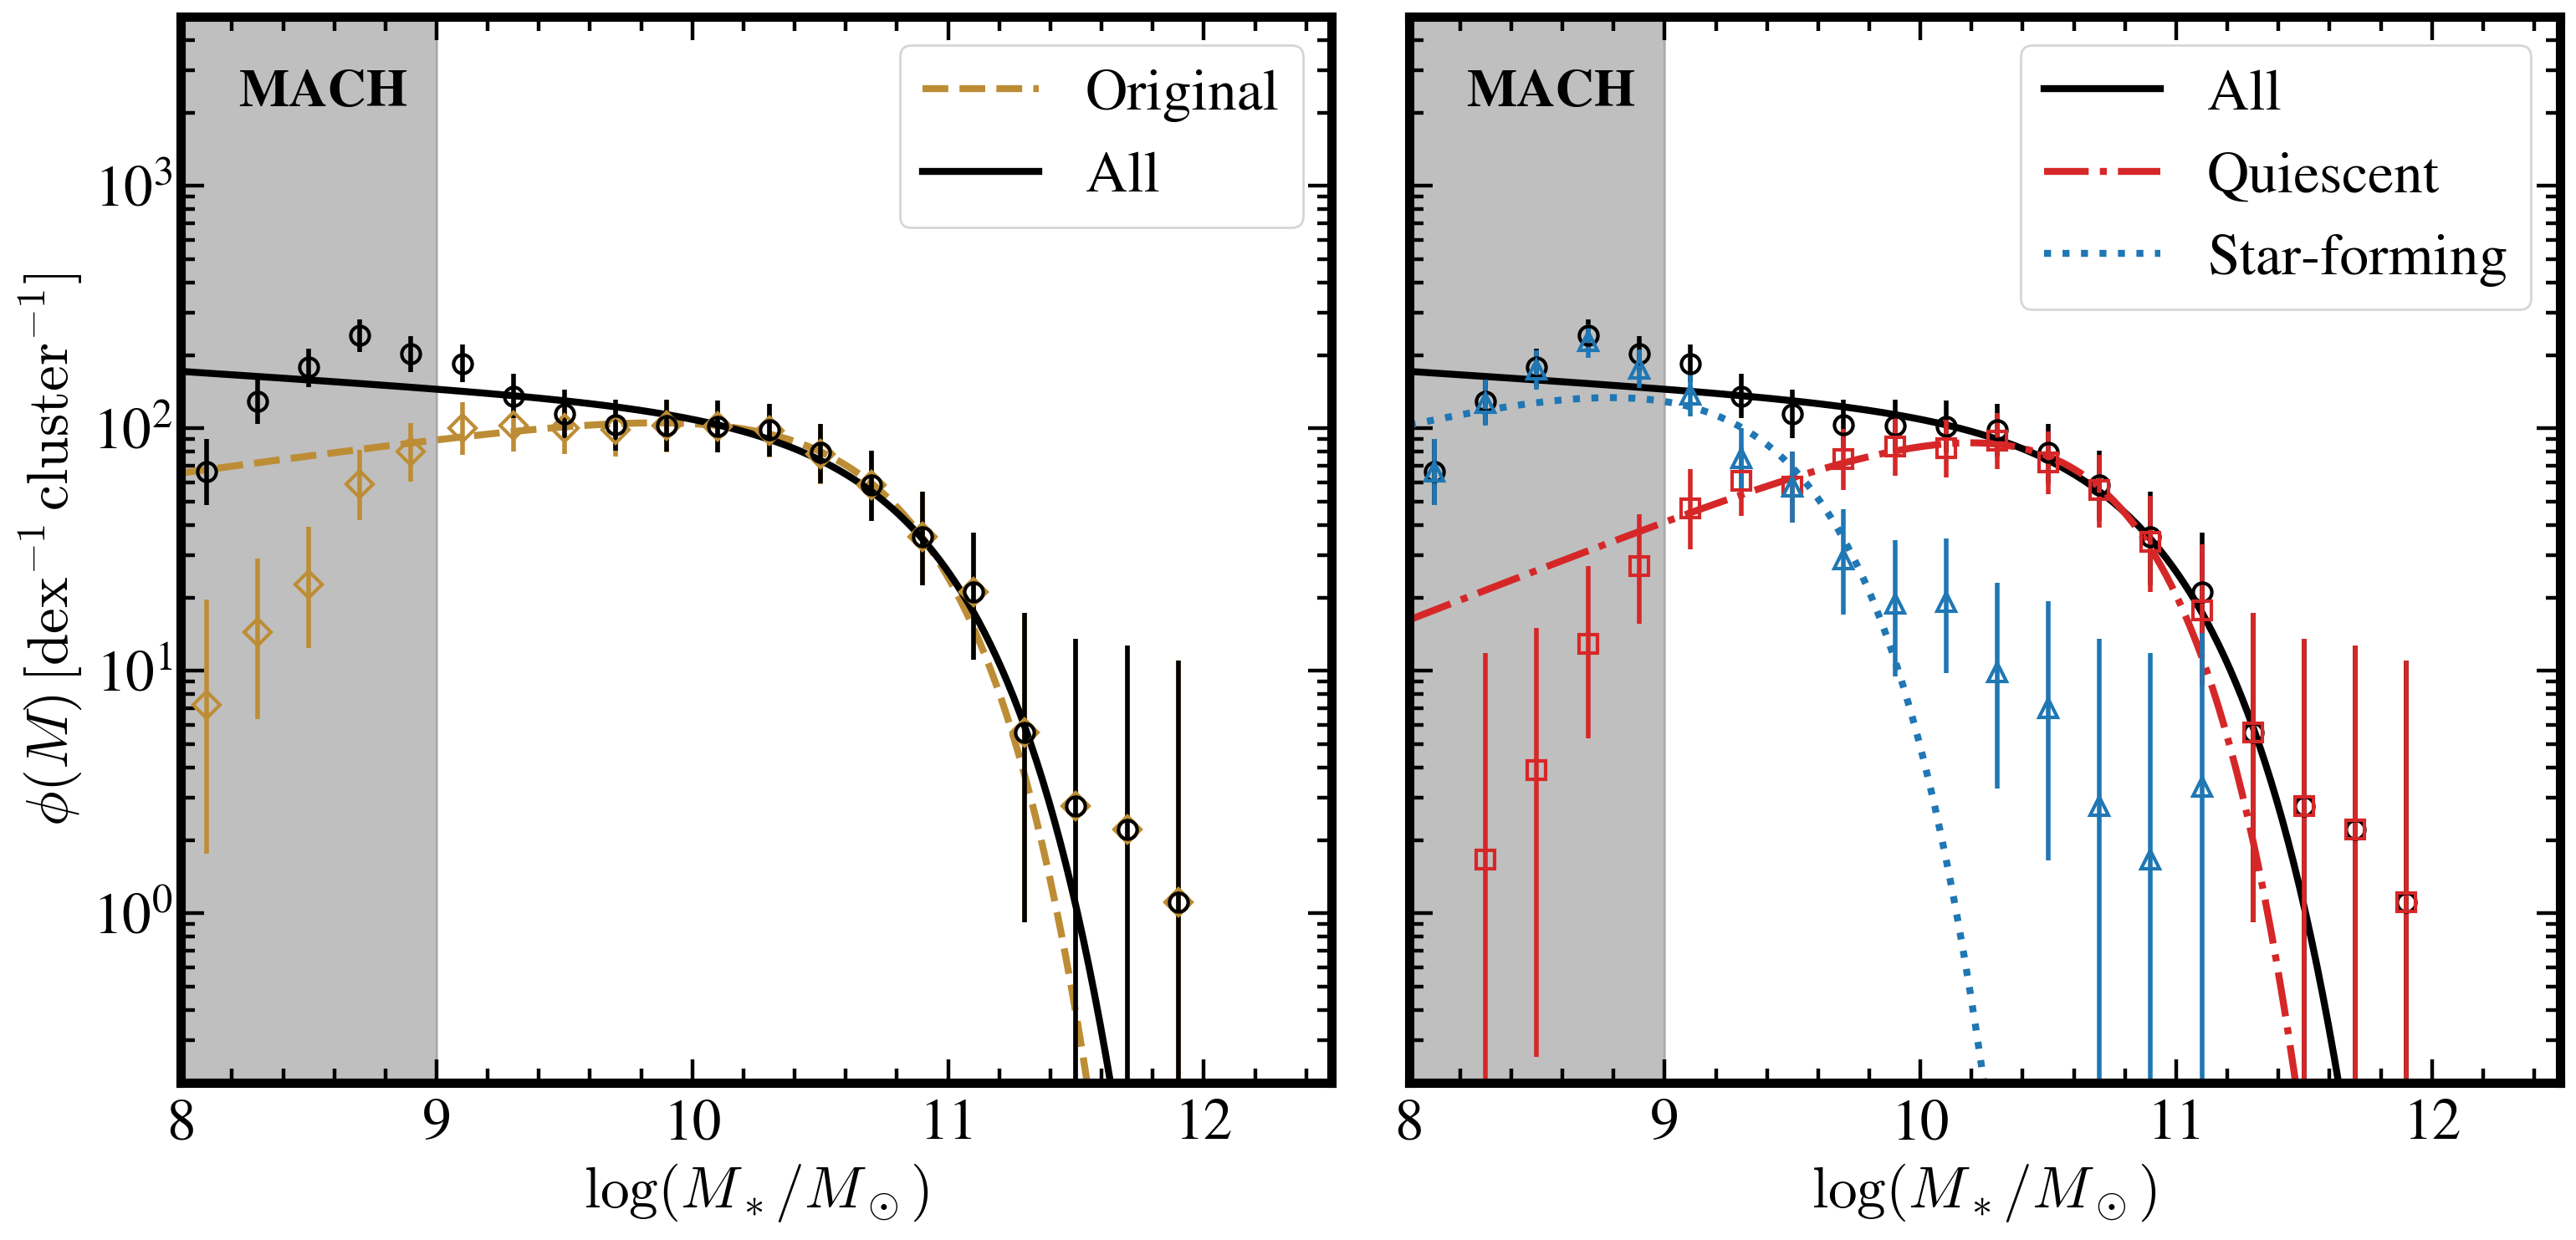

In [8]:
# =============================================================
# MCMC Schechter-function fitting
#   Fits a single Schechter function to each of four SMF datasets
#   (Original, All, Quiescent, Star-forming) using emcee MCMC.
#   Returns median parameter estimates with 1-σ asymmetric errors.
# =============================================================

# --- MCMC hyperparameters ---
ndim       = 3     # free parameters: (phi_0, M_star, alpha)
nwalkers   = 256   # number of ensemble walkers
burn_steps = 100   # burn-in steps (discarded)
prod_steps = 500   # production steps (used for posteriors)

# --- Initial parameter guesses per dataset: (phi_0, M_star, alpha) ---
initial_guesses = {
    'All':          np.array([333, 10.65, -1.00]),
    'Quiescent':    np.array([100, 10.70, -1.00]),
    'Star-forming': np.array([200, 10.10, -1.40]),
    'Original':     np.array([150, 10.50, -1.00]),
}

# --- Plot style per dataset ---
colors = {
    'All':          '#000000',   # black
    'Original':     '#bd8d35',   # brown/gold
    'Star-forming': '#1f77b4',   # blue
    'Quiescent':    '#d62728',   # red
}
marker_symbols = {
    'All':          'o',
    'Quiescent':    's',
    'Star-forming': '^',
    'Original':     'D',
}
line_styles = {
    'All':          '-',    # solid
    'Original':     '--',   # dashed
    'Quiescent':    '-.',   # dash-dot
    'Star-forming': ':',    # dotted
}

# --- Panel groupings for the multi-panel comparison plot ---
panels = {
    0: ['Original', 'All'],
    1: ['All', 'Quiescent', 'Star-forming'],
}

# Legend labels (internal dataset keys stay Original / All / …)
legend_labels = {
    'Original': 'Raw SMF',
    'All': 'Corrected SMF',
    'Quiescent': 'Quiescent',
    'Star-forming': 'Star-forming',
}

# =============================================================
# Schechter function model
#   Φ(M) = ln(10) · φ₀ · 10^[(1+α)(M−M*)] · exp(−10^(M−M*))
#   where M = log₁₀(M★/M☉)
# =============================================================
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    x = M - M_star
    return np.log(10) * phi_0 * 10 ** ((1 + alpha) * x) * np.exp(-10 ** x)

# =============================================================
# Bayesian components for emcee
# =============================================================
def log_prior(theta):
    """Flat (uniform) prior; returns 0 inside bounds, -inf outside."""
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 1e4 and 8 < M_star < 14 and -5 < alpha < 5:
        return 0.0
    return -np.inf

def log_likelihood(theta, x, y, yerr):
    """Gaussian log-likelihood with per-point errors."""
    model = schechter_1D_SMF(x, *theta)
    return -0.5 * np.sum((y - model) ** 2 / yerr ** 2 + np.log(2 * np.pi * yerr ** 2))

def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, x, y, yerr) if np.isfinite(lp) else -np.inf

# =============================================================
# MCMC fitting routine
#   Returns (median, lower_1sigma, upper_1sigma) for each parameter.
# =============================================================
def fit_schechter_mcmc(x, y, yerr, initial):
    # Initialise walkers near the starting point with tiny Gaussian scatter
    pos     = initial + 1e-4 * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(x, y, yerr))

    # Burn-in: let walkers explore and discard early samples
    sampler.run_mcmc(pos, burn_steps, progress=True)
    sampler.reset()

    # Production run
    sampler.run_mcmc(None, prod_steps, progress=True)
    samples = sampler.get_chain(flat=True)

    # Summarise posteriors via 16th / 50th / 84th percentiles (≈ median ± 1σ)
    p16, p50, p84 = np.percentile(samples, [16, 50, 84], axis=0)
    return p50, p50 - p16, p84 - p50    # median, lower_err, upper_err

# =============================================================
# Run fits for every dataset
#   Input histograms are normalised to a number density:
#     Φ = counts / bin_width   [dex⁻¹ per cluster]
#   Poisson-like upper error:
#     σ = (√(N + 0.75) + 1) / bin_width   (Gehrels 1986 approximation)
#   Only bins above SMF_complimit with Φ > 0 are fitted.
# =============================================================
datasets = {
    'Original':     original_counts,
    'All':          mean_all,
    'Quiescent':    mean_q,
    'Star-forming': mean_sf,
}
TARGET = 'MACH'

# --- 2) Plot using pre-computed fits ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
for idx, labels in panels.items():
    ax = axes[idx]
    # shade region below completeness limit
    ax.axvspan(8, SMF_complimit, color='gray', alpha=0.5)
    for label in labels:
        hist      = datasets[label]
        hist_norm = hist / bin_width
        yerr_up   = (np.sqrt(hist + 0.75) + 1) / bin_width
        yerr_low  = np.sqrt(np.clip(hist - 0.25, 0.25, None)) / bin_width
        # Left panel only: hollow squares for Original vs All; right panel keeps marker_symbols
        m = 's' if idx == 0 else marker_symbols[label]

        # data points (hollow)
        ax.errorbar(
            bin_centers[hist > 0], hist_norm[hist > 0],
            yerr=[yerr_low[hist > 0], yerr_up[hist > 0]],
            fmt=m,
            color=colors[label],
            markerfacecolor='none',
            markeredgecolor=colors[label],
            markersize=8,
            markeredgewidth=1.5,
            ecolor=colors[label],
            capsize=0
        )

        # best-fit curve over full mass range
        phi0, Mstar, alpha = fit_results[label][0]
        M_fit = np.linspace(8, 12.5, 200)
        ax.plot(
            M_fit,
            schechter_1D_SMF(M_fit, phi0, Mstar, alpha),
            color=colors[label],
            lw=3,
            linestyle=line_styles[label],
            label=legend_labels[label]
        )

    # styling
    ax.set_yscale('log')
    ax.set_xlim(8, 12.5)
    ax.set_ylim(0.2, 5000)
    ax.set_xlabel(r'$\log(M_*/M_\odot)$')
    if idx == 0:
        ax.set_ylabel(r'$\phi(M)\,[\mathrm{dex}^{-1}\,\mathrm{cluster}^{-1}]$')
    ax.legend()
    
    # Add annotations for MACH (top-left) and parameter values (bottom-left)
    ax.text(0.05, 0.95, f'{TARGET}', transform=ax.transAxes, fontsize=23, weight='bold', va='top', ha='left', color='black')

plt.tight_layout()
plt.show()

## Single-panel figure (for presentations)

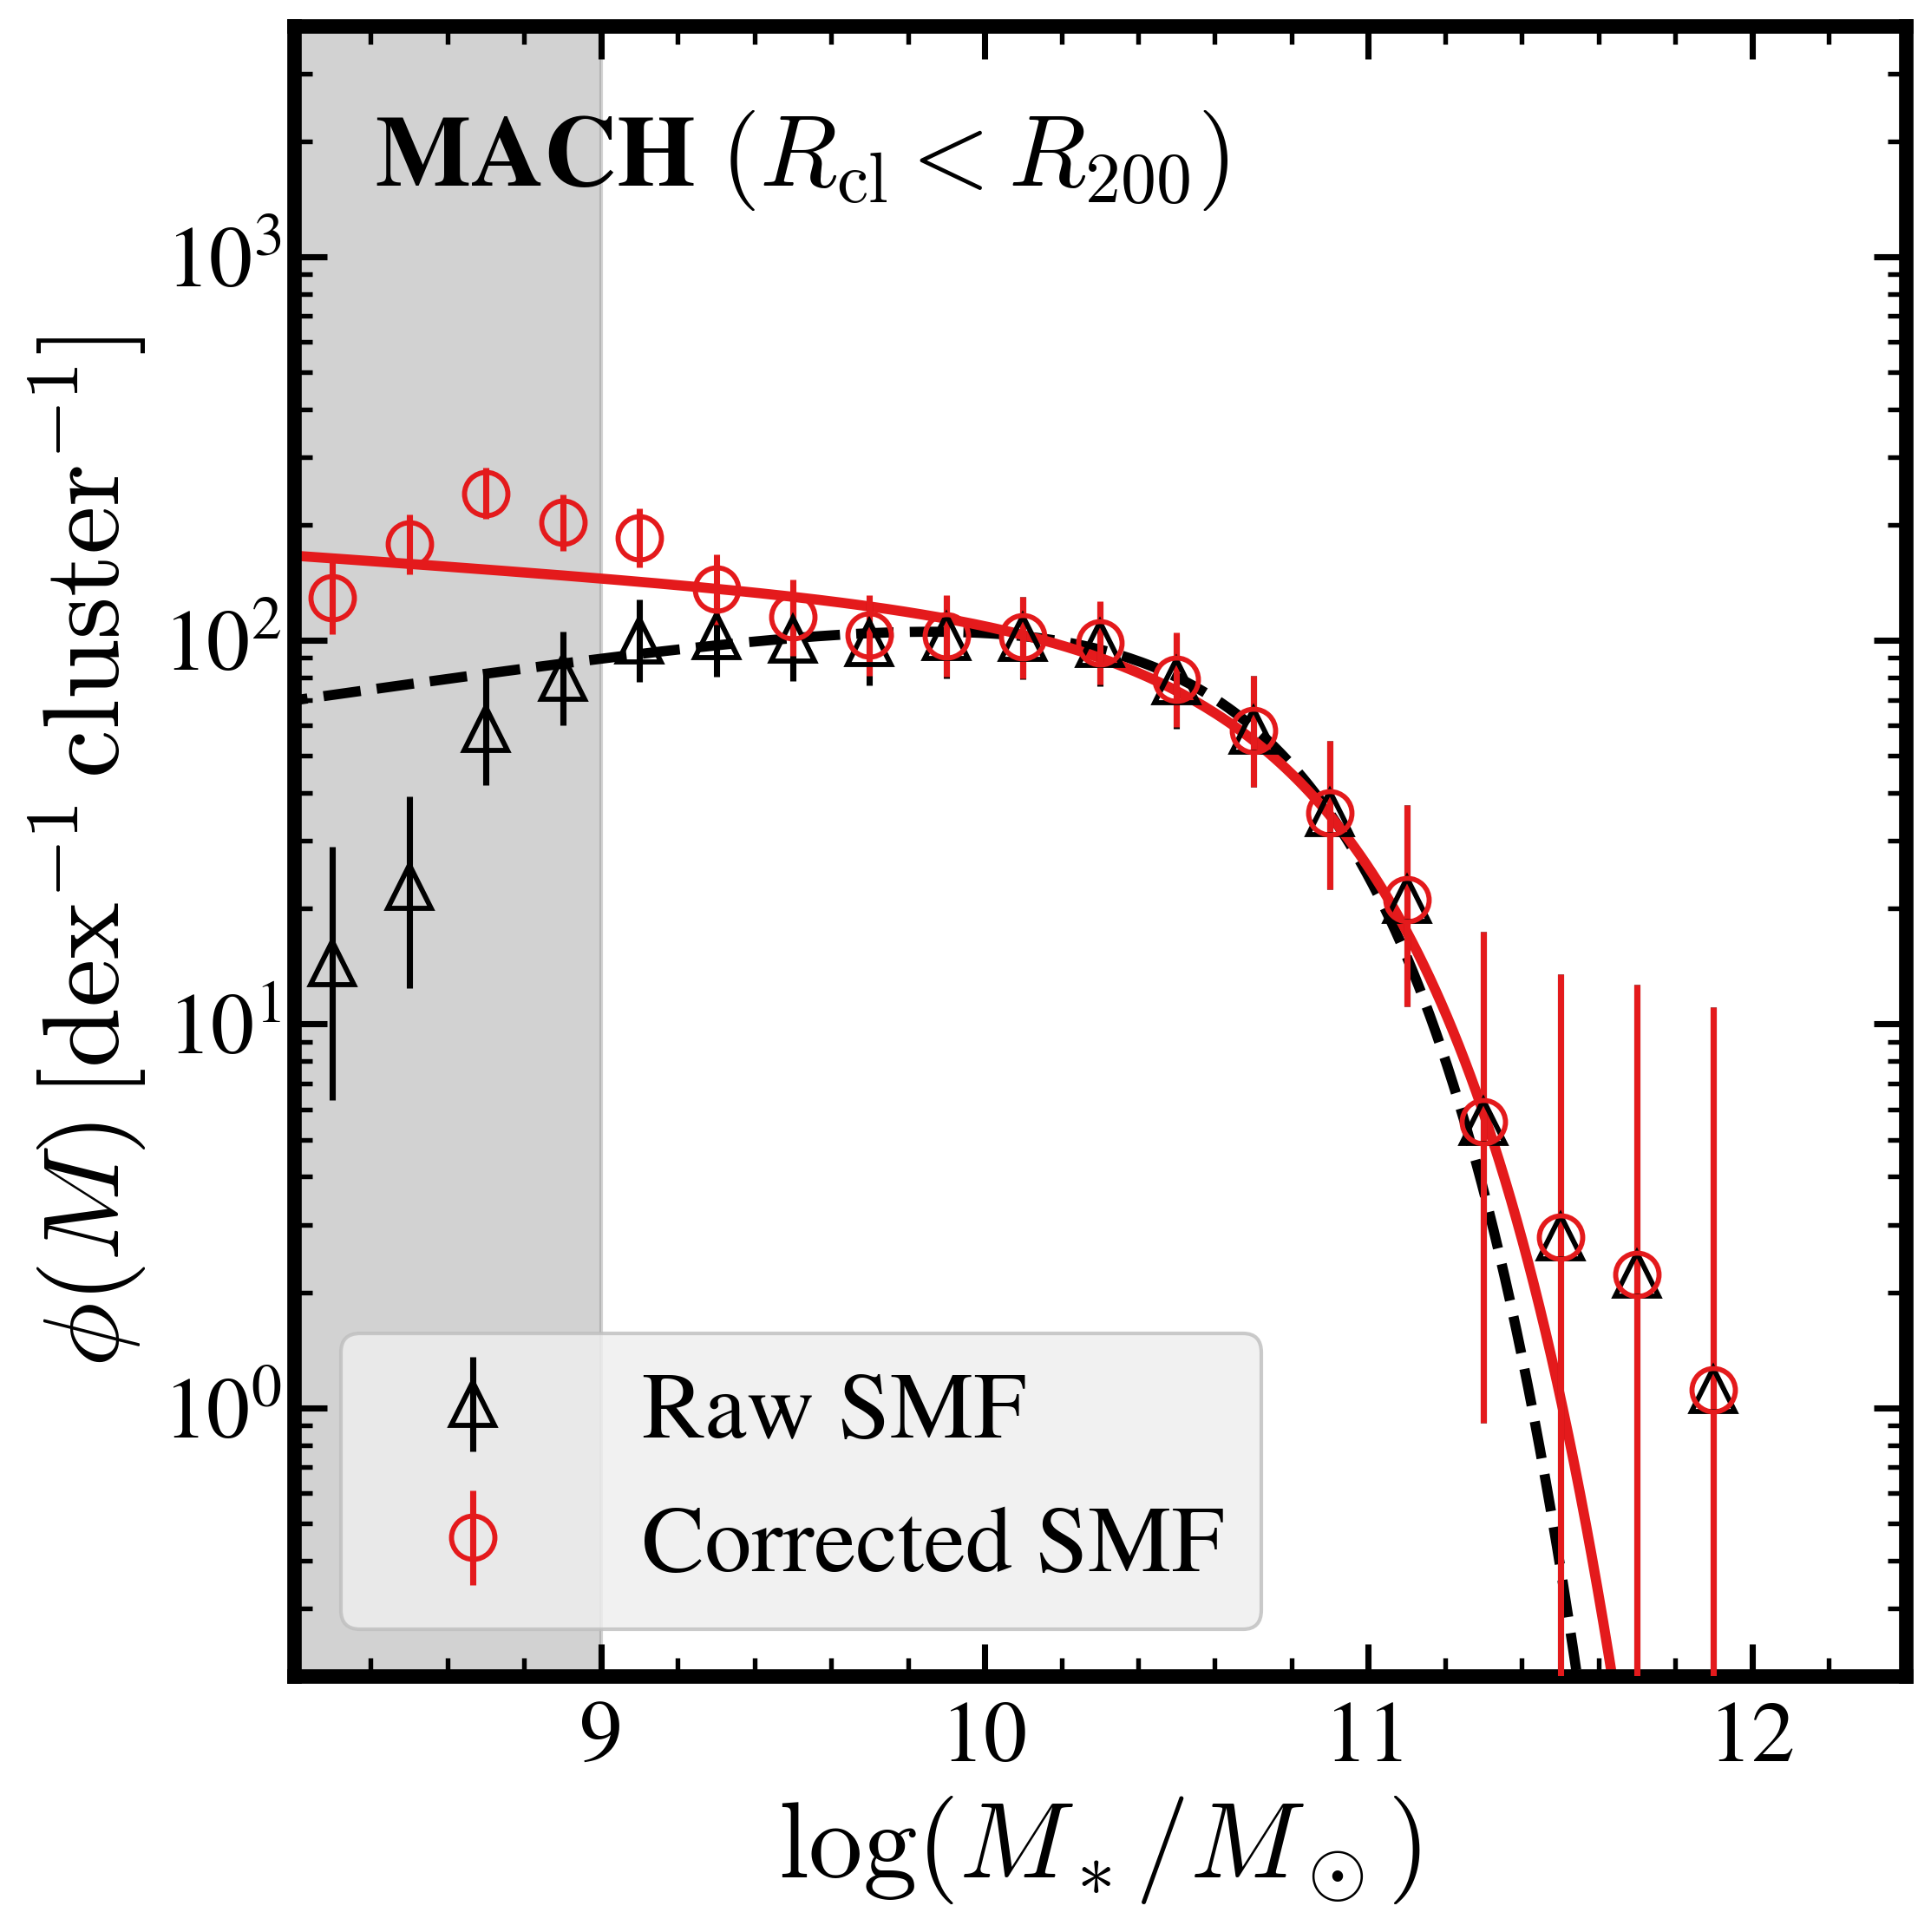

In [17]:
# ------------------------------------------------------------------
# Single panel: raw SMF (black triangles, dashed fit) and corrected SMF (red circles, solid fit)
# ------------------------------------------------------------------
TARGET = "MACH"

raw_hist = original_counts     # Raw SMF
cor_hist = mean_all            # Corrected SMF

fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

# Background + completeness shaded region
ax.set_facecolor("white")
ax.axvspan(8.0, SMF_complimit, color="gray", alpha=0.35, zorder=0)

def plot_smf_points(hist, color, marker, label):
    y = hist / bin_width
    yerr_up  = (np.sqrt(hist + 0.75) + 1.0) / bin_width
    yerr_low = np.sqrt(np.clip(hist - 0.25, 0.25, None)) / bin_width
    m = hist > 0

    ax.errorbar(
        bin_centers[m], y[m],
        yerr=[yerr_low[m], yerr_up[m]],
        fmt=marker,
        color=color,
        markerfacecolor="none",
        markeredgecolor=color,
        markeredgewidth=1.4,
        markersize=12,
        ecolor=color,
        elinewidth=1.7,
        capsize=0,
        linestyle="none",
        label=label,
        zorder=3
    )

# Data points
plot_smf_points(raw_hist, "black", "^", "Raw SMF")
plot_smf_points(cor_hist, "#e41a1c", "o", "Corrected SMF")

# Best-fit curves from fit_results
M_fit = np.linspace(8.0, 12.5, 300)

phi0_r, Mstar_r, alpha_r = fit_results["Original"][0]
phi0_c, Mstar_c, alpha_c = fit_results["All"][0]

ax.plot(
    M_fit,
    schechter_1D_SMF(M_fit, phi0_r, Mstar_r, alpha_r),
    color="black",
    lw=2.8,
    ls="--",
    zorder=2
)
ax.plot(
    M_fit,
    schechter_1D_SMF(M_fit, phi0_c, Mstar_c, alpha_c),
    color="#e41a1c",
    lw=2.8,
    ls="-",
    zorder=2
)

# Axes styling
ax.set_yscale("log")
ax.set_xlim(8.2, 12.4)
ax.set_ylim(0.2, 4e3)

ax.set_xlabel(r"$\log(M_\ast/M_\odot)$")
ax.set_ylabel(r"$\phi(M)\,[\mathrm{dex}^{-1}\,\mathrm{cluster}^{-1}]$")

ax.tick_params(
    axis="both", which="major",
    direction="in", length=9, width=1.7, top=True, right=True
)
ax.tick_params(
    axis="both", which="minor",
    direction="in", length=5, width=1.3, top=True, right=True
)

# Panel title text (top-left)
ax.text(
    0.05, 0.95,
    rf"{TARGET} $(R_{{\rm cl}} < R_{{200}})$",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=28, weight="bold", color="black"
)

# Legend (lower-left translucent box)
leg = ax.legend(
    loc="lower left",
    frameon=True,
    fancybox=True,
    framealpha=0.82
)
leg.get_frame().set_facecolor("#efefef")
leg.get_frame().set_edgecolor("#bfbfbf")

plt.tight_layout()
plt.show()